# CodeAlpha - Unemployment Analysis with Python

This project analyzes unemployment trends in India using Python. The analysis covers data cleaning, monthly trends, state-wise comparison, COVID-19 period analysis, correlation, and key observations.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load Dataset

In [13]:
# Public copy of the CodeAlpha-style unemployment dataset
url = 'https://raw.githubusercontent.com/SaiyamTuteja/EMPLOYMENT_AND_UNEMPLOYMENT_DATA_ANALYSIS/master/Unemployment_Rate_upto_11_2020.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

print('Dataset loaded successfully!')
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 2. Understand the Dataset

In [14]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

print('\nSummary statistics:')
display(df.describe(include='all'))

Columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

Data types:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
long

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
count,267,267,267,267.000000,2.670000e+02,267.000000,267,267.000000,267.000000
unique,27,10,1,NaN,NaN,NaN,5,NaN,NaN
top,Andhra Pradesh,31-05-2020,M,NaN,NaN,NaN,North,NaN,NaN
freq,10,27,267,NaN,NaN,NaN,79,NaN,NaN
mean,NaN,NaN,NaN,12.236929,1.396211e+07,41.681573,NaN,22.826048,80.532425
std,NaN,NaN,NaN,10.803283,1.336632e+07,7.845419,NaN,6.270731,5.831738
min,NaN,NaN,NaN,0.500000,1.175420e+05,16.770000,NaN,10.850500,71.192400
25%,NaN,NaN,NaN,4.845000,2.838930e+06,37.265000,NaN,18.112400,76.085600
50%,NaN,NaN,NaN,9.650000,9.732417e+06,40.390000,NaN,23.610200,79.019300
75%,NaN,NaN,NaN,16.755000,2.187869e+07,44.055000,NaN,27.278400,85.279900


## 3. Data Cleaning and Preparation

In [15]:
# Standardize column names and remove accidental spaces in text fields
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Convert numeric columns safely
numeric_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

before = len(df)
df = df.drop_duplicates().dropna(subset=['Date'] + numeric_cols).copy()
after = len(df)

df['Month'] = df['Date'].dt.to_period('M').astype(str)

print(f'Removed {before - after} incomplete/duplicate rows.')
print('Cleaned shape:', df.shape)
display(df.head())

Removed 0 incomplete/duplicate rows.
Cleaned shape: (267, 10)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,2020-01
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2020-02
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,2020-03
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,2020-04
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,2020-05


## 4. Overall Unemployment Trend

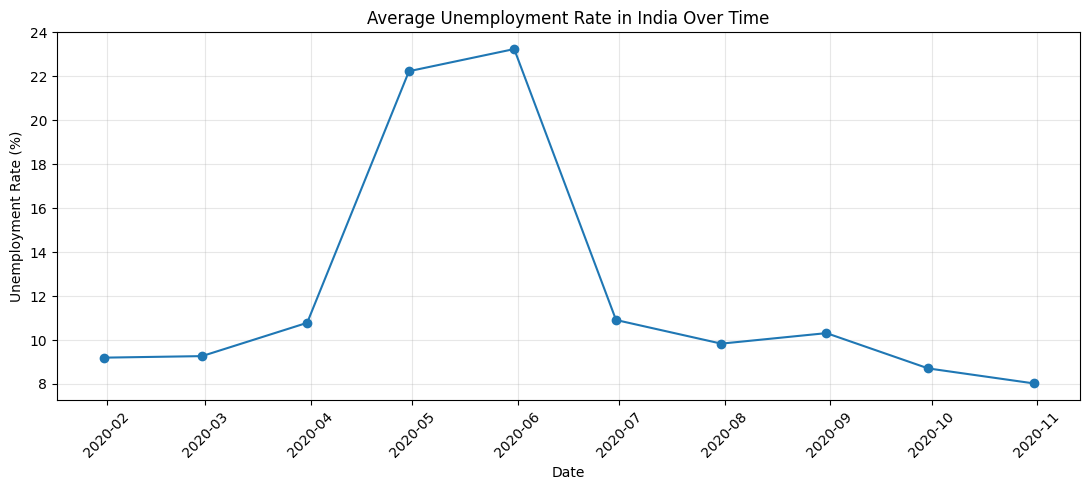

In [16]:
monthly = (df.groupby('Date', as_index=False)['Estimated Unemployment Rate (%)']
             .mean()
             .sort_values('Date'))

plt.figure(figsize=(11, 5))
plt.plot(monthly['Date'], monthly['Estimated Unemployment Rate (%)'], marker='o')
plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. State-wise Unemployment Analysis

Top 10 regions by average unemployment rate:


,Average Unemployment Rate (%)
Region,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


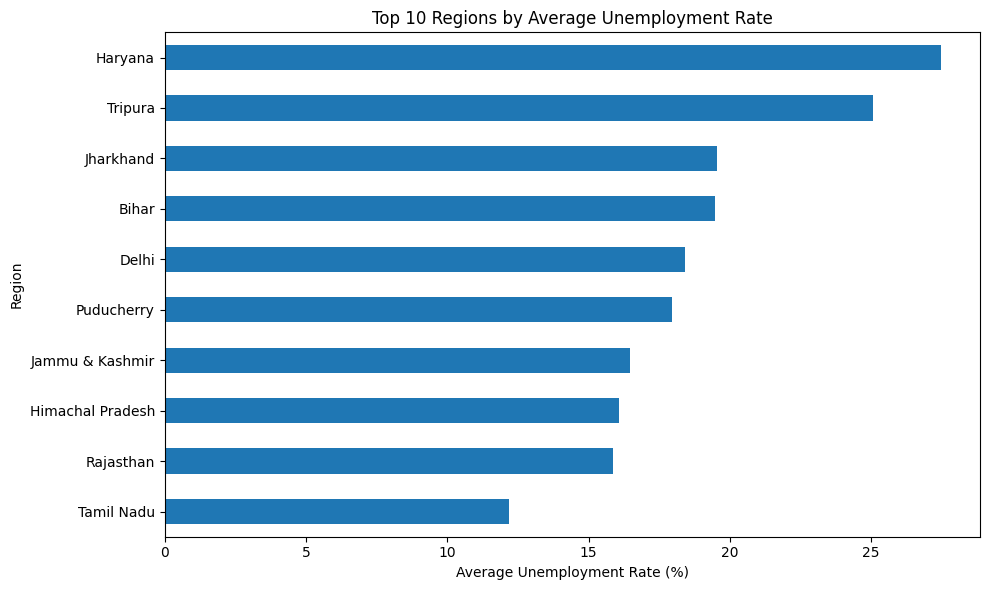

In [17]:
state_avg = (df.groupby('Region')['Estimated Unemployment Rate (%)']
               .mean()
               .sort_values(ascending=False))

print('Top 10 regions by average unemployment rate:')
display(state_avg.head(10).to_frame('Average Unemployment Rate (%)'))

plt.figure(figsize=(10, 6))
state_avg.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## 6. COVID-19 Period Analysis

,mean,min,max
Period,,,
Apr-Oct 2020,13.28,0.50,75.85
Jan-Mar 2020,9.76,0.58,32.67


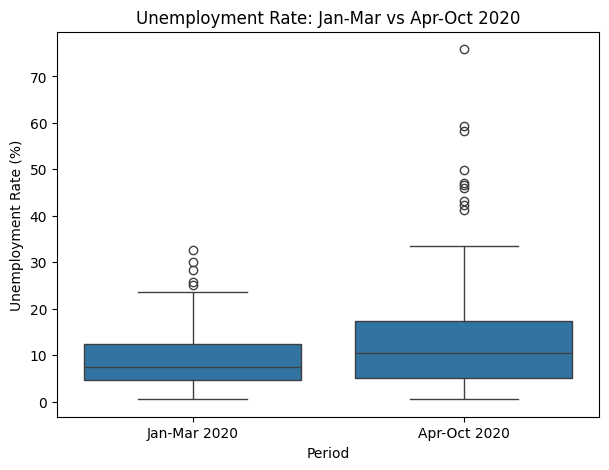

In [18]:
# The dataset covers 2020 monthly observations. We compare Jan-Mar with Apr-Oct
# as a simple before/after comparison around the period when COVID-19 restrictions began.
df['Period'] = np.where(df['Date'] < pd.Timestamp('2020-04-01'), 'Jan-Mar 2020', 'Apr-Oct 2020')

period_summary = df.groupby('Period')['Estimated Unemployment Rate (%)'].agg(['mean','min','max']).round(2)
display(period_summary)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Period', y='Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate: Jan-Mar vs Apr-Oct 2020')
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.show()

## 7. Highest Monthly Unemployment

In [19]:
peak_row = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]
print('Highest recorded unemployment observation in this dataset:')
print('Region:', peak_row['Region'])
print('Date:', peak_row['Date'].date())
print('Unemployment Rate (%):', round(peak_row['Estimated Unemployment Rate (%)'], 2))

monthly_peak = monthly.loc[monthly['Estimated Unemployment Rate (%)'].idxmax()]
print('\nHighest national average month in this dataset:')
print('Date:', monthly_peak['Date'].date())
print('Average rate (%):', round(monthly_peak['Estimated Unemployment Rate (%)'], 2))

Highest recorded unemployment observation in this dataset:
Region: Puducherry
Date: 2020-04-30
Unemployment Rate (%): 75.85

Highest national average month in this dataset:
Date: 2020-05-31
Average rate (%): 23.24


## 8. Correlation Analysis

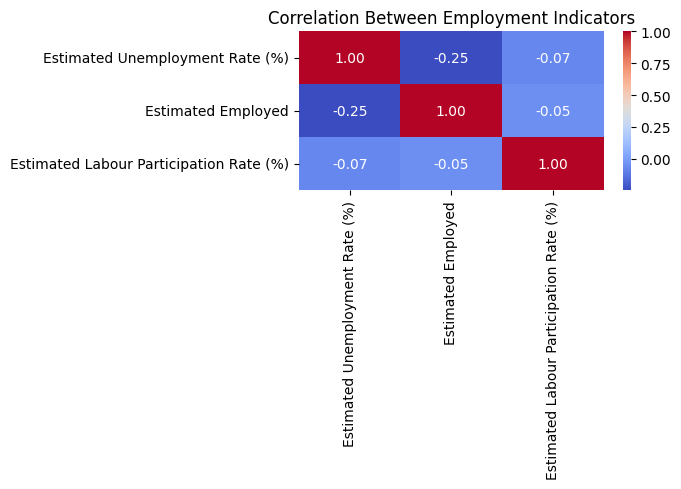

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


In [20]:
corr_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Employment Indicators')
plt.tight_layout()
plt.show()

display(df[corr_cols].corr())

## 9. Employment vs Unemployment

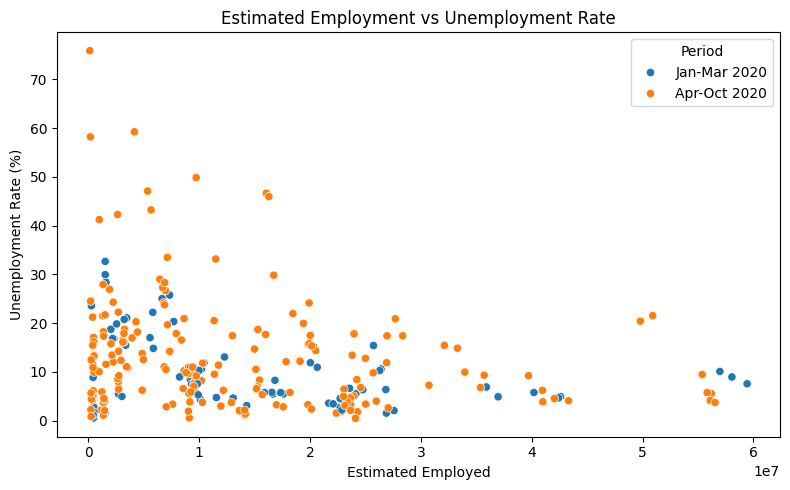

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    hue='Period'
)
plt.title('Estimated Employment vs Unemployment Rate')
plt.xlabel('Estimated Employed')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

## 10. Key Insights

In [22]:
pre_avg = period_summary.loc['Jan-Mar 2020', 'mean']
post_avg = period_summary.loc['Apr-Oct 2020', 'mean']
change = post_avg - pre_avg

print('Key observations:')
print(f'- Average unemployment rate for Jan-Mar 2020: {pre_avg:.2f}%')
print(f'- Average unemployment rate for Apr-Oct 2020: {post_avg:.2f}%')
print(f'- Change between the two periods: {change:+.2f} percentage points')
print('- Unemployment rates vary considerably across regions.')
print('- The monthly trend helps identify periods of unusually high unemployment.')
print('- Employment and labour participation indicators provide additional context for interpreting unemployment.')

Key observations:
- Average unemployment rate for Jan-Mar 2020: 9.76%
- Average unemployment rate for Apr-Oct 2020: 13.28%
- Change between the two periods: +3.52 percentage points
- Unemployment rates vary considerably across regions.
- The monthly trend helps identify periods of unusually high unemployment.
- Employment and labour participation indicators provide additional context for interpreting unemployment.


## Conclusion

This project analyzed unemployment data in India using Python. The dataset was cleaned and prepared before performing exploratory analysis. Monthly trends, regional differences, COVID-19 period comparisons, and relationships between employment indicators were studied using charts and summary statistics. The analysis shows how Python can be used to identify important patterns in real-world economic data and communicate those findings clearly.